In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [4]:
data = pd.read_csv('/workspaces/Customer-Credit-Default-Prediction/dataset.csv')

In [5]:
data.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32577.00,32577.00,31682.00,32577.00,29461.00,32577.00,32577.00,32577.00
mean,27.72,65882.51,4.79,9589.44,11.01,0.22,0.17,5.80
std,6.20,52534.22,4.09,6322.05,3.24,0.41,0.11,4.05
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,94.00,2039784.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [6]:
data.shape


(32577, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32577 entries, 0 to 32576
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32577 non-null  int64  
 1   person_income               32577 non-null  int64  
 2   person_home_ownership       32577 non-null  object 
 3   person_emp_length           31682 non-null  float64
 4   loan_intent                 32577 non-null  object 
 5   loan_grade                  32577 non-null  object 
 6   loan_amnt                   32577 non-null  int64  
 7   loan_int_rate               29461 non-null  float64
 8   loan_status                 32577 non-null  int64  
 9   loan_percent_income         32577 non-null  float64
 10  cb_person_default_on_file   32577 non-null  object 
 11  cb_person_cred_hist_length  32577 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,1.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Data preprocessing

In [9]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [10]:
data['person_emp_length'].fillna(data['person_emp_length'].median(), inplace=True)
data['loan_int_rate'].fillna(data['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_36705/2598716969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['person_emp_length'].fillna(data['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_36705/2598716969.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [11]:
data_n = pd.get_dummies(data, drop_first=True)

In [12]:
data_n.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,1.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [13]:
data_n.isnull().sum()

person_age                     0
person_income                  0
person_emp_length              0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_cred_hist_length     0
person_home_ownership_OTHER    0
person_home_ownership_OWN      0
person_home_ownership_RENT     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
loan_grade_B                   0
loan_grade_C                   0
loan_grade_D                   0
loan_grade_E                   0
loan_grade_F                   0
loan_grade_G                   0
cb_person_default_on_file_Y    0
dtype: int64

In [14]:
X = data_n.drop('loan_status', axis=1)
y = data_n['loan_status']

## Train–test split

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Logistic regression model

In [17]:
from sklearn import linear_model
log_model = linear_model.LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)

/workspaces/Customer-Credit-Default-Prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [18]:
log_model.predict_proba(X_test_scaled)[:,-1].round(3)

array([0.016, 0.186, 0.017, ..., 0.255, 0.015, 0.294])

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

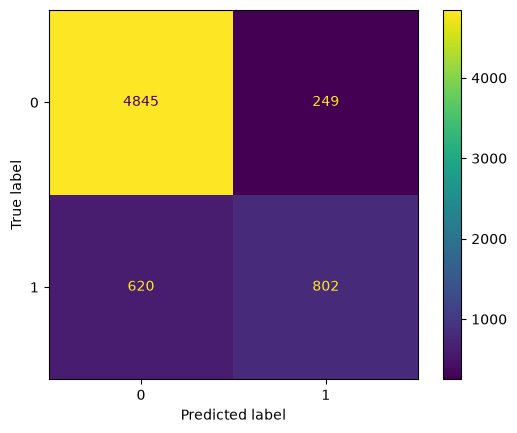

In [20]:
disp.plot()

##Logistic regression performance

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5094
           1       0.76      0.56      0.65      1422

    accuracy                           0.87      6516
   macro avg       0.82      0.76      0.78      6516
weighted avg       0.86      0.87      0.86      6516



In [22]:
# Import metrics from scikit-learn
from sklearn.metrics import precision_score, recall_score, accuracy_score, roc_auc_score, RocCurveDisplay

In [23]:
# Calculate Precision score
precision= precision_score(y_test, y_pred_log)
print(f'Precision: {precision:.3f}')

Precision: 0.763


In [24]:
# Calculate Recall score
recall = recall_score(y_test, y_pred_log)
print(f'Recall {recall:.3f}')

Recall 0.564


In [25]:
# Calculate Accuracy score
accuracy = accuracy_score(y_test, y_pred_log)
print(f'Accuracy {accuracy:.3f}')

Accuracy 0.867


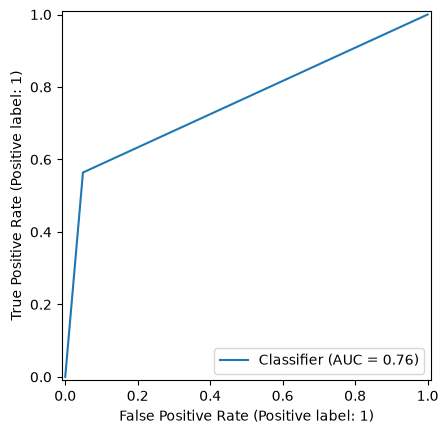

In [26]:
# Graph ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_log)

In [27]:
# Calculate AUC score
auc = roc_auc_score(y_test, y_pred_log)
print(f'Auc {auc:.3f}')

Auc 0.758


##Decision Tree Model

In [28]:
# Instantiate the model
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=0)

In [29]:
# Fit the model to training data
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [30]:
# Make predictions on test data
y_pred_test = decision_tree.predict(X_test)

##Decision tree performance

In [31]:
# Generate performance metrics
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
print('Accuracy: {0:.3f}'.format(accuracy_score(y_test, y_pred_test)))
print('Precision: {0:.3f}'.format(precision_score(y_test, y_pred_test)))
print('Recall: {0:.3f}'.format(recall_score(y_test, y_pred_test)))
print('F1 Score: {0:.3f}'.format(f1_score(y_test, y_pred_test)))

Accuracy: 0.891
Precision: 0.738
Recall: 0.773
F1 Score: 0.755


In [32]:
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

tree_auc = roc_auc_score(y_test, y_prob_tree)
print(f"AUC: {tree_auc:.3f}")

AUC: 0.848


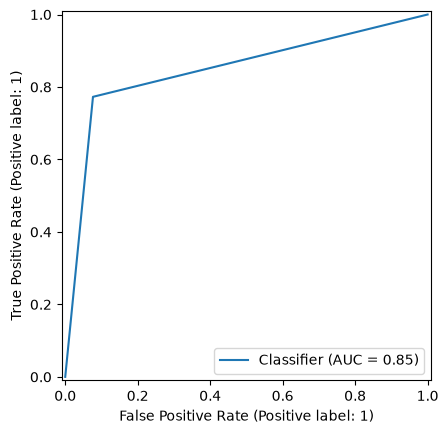

In [33]:
RocCurveDisplay.from_predictions(y_test, y_prob_tree)

In [34]:
def conf_matrix_plot(model, X, y):

    model_pred = model.predict(X)
    cm = confusion_matrix(y, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)

    disp.plot(values_format='')
    plt.show()

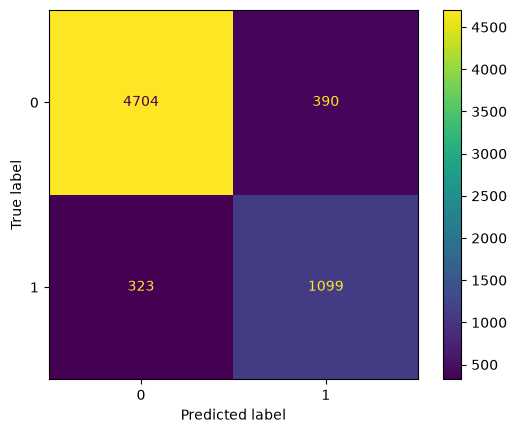

In [35]:
# Generate confusion matrix
conf_matrix_plot(decision_tree, X_test, y_test)

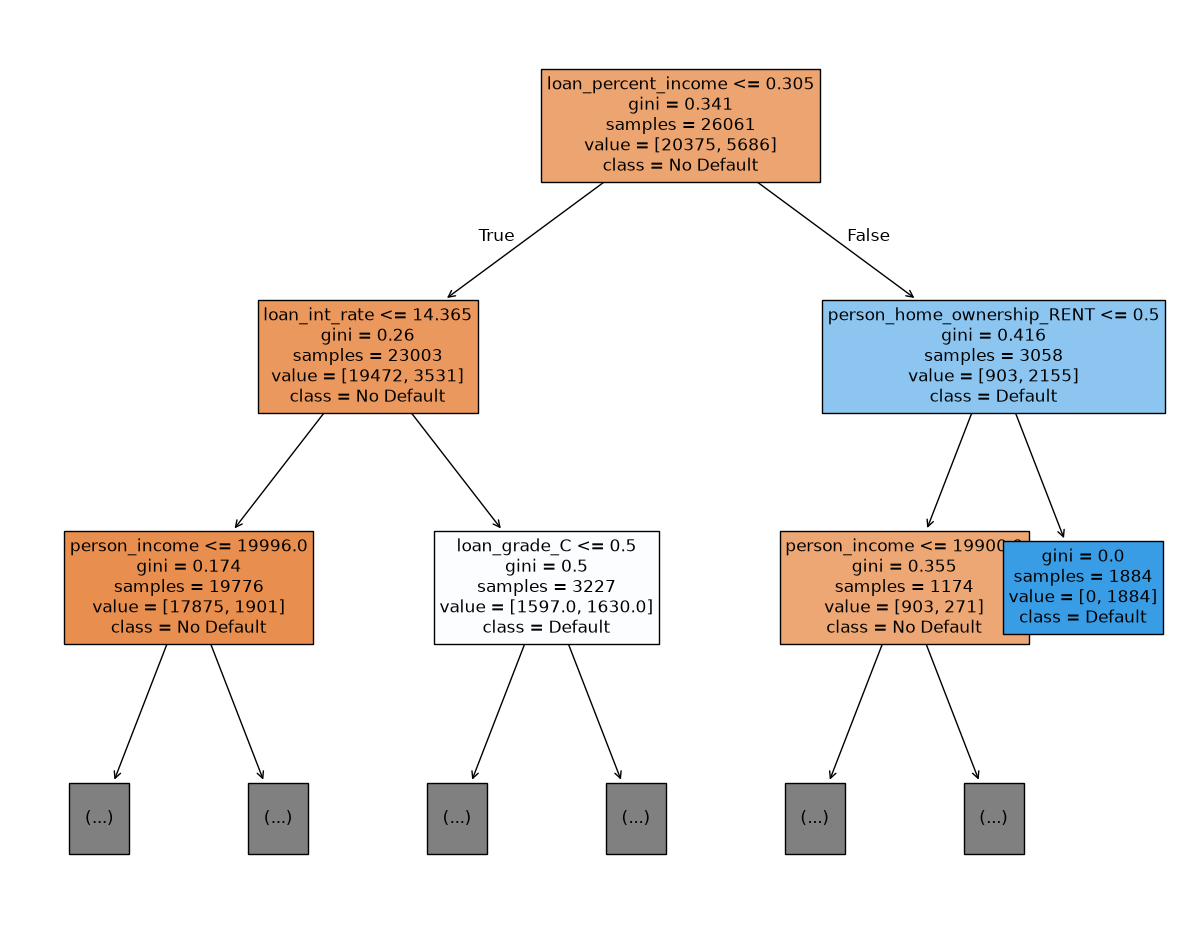

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,12))

plot_tree(decision_tree,
    max_depth=2,
    fontsize=12,
    feature_names=X.columns,
    class_names=['No Default', 'Default'],
    filled=True
)

plt.show()

##Comparative summary of model performance

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],'Accuracy': [accuracy_score(y_test, y_pred_log),accuracy_score(y_test, y_pred_test)],
    'Precision_default': [precision_score(y_test, y_pred_log),precision_score(y_test, y_pred_test)],
    'Recall_default': [recall_score(y_test, y_pred_log),recall_score(y_test, y_pred_test)],
    'F1_default': [f1_score(y_test, y_pred_log),f1_score(y_test, y_pred_test)],
    'AUC': [roc_auc_score(y_test, y_pred_log),roc_auc_score(y_test, y_pred_test)]})

results

,Model,Accuracy,Precision_default,Recall_default,F1_default,AUC
0,Logistic Regression,0.866636,0.763083,0.563994,0.648605,0.757557
1,Decision Tree,0.890577,0.738079,0.772855,0.755067,0.848147
